In [2]:
import os

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

from ml_ica.tools import whitening, callback
from ml_ica.algorithms import (picard, simple_quasi_newton_ica, truncated_ica,
                               trust_region_ica)


'''
Choose dataset
'''
dataset = 'eeg'
# dataset = 'fmri'

'''
Fetch dataset
'''
rng = np.random.RandomState(0)
current_directory = os.getcwd()

X = np.loadtxt("/Users/caleblee/Downloads/X_whitened.csv",
               delimiter=",", dtype=np.float64)

# filename = "/Users/caleblee/Downloads/X_whitened.csv"
# X = loadmat(filename)['X']


'''
Preprocess the signals
'''
X -= np.mean(X, axis=1, keepdims=True)
X, _ = whitening(X)
n_features, n_samples = X.shape

'''
Specify the tolerance and maximum number of iterations
'''

tol = 1e-4
max_iter = 500

# '''
# Run each algorithm on the dataset and plot the gradient curves
# '''

# algorithm_list = [truncated_ica, trust_region_ica, simple_quasi_newton_ica,
#                   picard]
# algorithm_names = ['Truncated Newton ICA', 'Trust region ICA',
#                    'Simple quasi-Newton ICA', 'Picard']

# print('''

# Running ica on %s dataset of size %d x %d...

# ''' % (dataset, n_features, n_samples))

# plt.figure()
# for algorithm, name in zip(algorithm_list, algorithm_names):
# #     if name != 'Trust region ICA':
#         cb = callback(['timing', 'gradient_norm'])
#         X_copy = X.copy()
#         print('Running  %s ...' % name)
#         algorithm(X_copy, verbose=1, callback=cb, tol=tol, max_iter=max_iter)
#         gradients = cb['gradient_norm']
#         times = cb['timing']
#         print('Took %.2g s / %d iterations to reach a gradient norm of %.2g.' %
#               (times[-1], len(times), max(gradients[-1], tol)))
#         print('Average time per iteration: %.2g sec' %
#               (times[-1] / len(times)))
#         plt.semilogy(times, gradients, label=name)
#         print('')

# plt.legend()
# plt.xlabel('Time (sec)')
# plt.ylabel('Gradient norm')
# plt.show()


algorithm_list = [picard]
algorithm_names = ['Picard']

print('''

Running ica on %s dataset of size %d x %d...

''' % (dataset, n_features, n_samples))

plt.figure()
for algorithm, name in zip(algorithm_list, algorithm_names):
#     if name != 'Trust region ICA':
        cb = callback(['timing', 'gradient_norm'])
        X_copy = X.copy()
        print('Running  %s ...' % name)
        algorithm(X_copy, verbose=0, callback=cb, tol=tol, max_iter=max_iter)
        gradients = cb['gradient_norm']
        times = cb['timing']
        print('Took %.2g s / %d iterations to reach a gradient norm of %.2g.' %
              (times[-1], len(times), max(gradients[-1], tol)))
        print('Average time per iteration: %.2g sec' %
              (times[-1] / len(times)))
        plt.semilogy(times, gradients, label=name)
        print('')

plt.legend()
plt.xlabel('Time (sec)')
plt.ylabel('Gradient norm')
plt.show()





Running ica on eeg dataset of size 314 x 229404...


Running  Truncated Newton ICA ...


/Users/caleblee/miniconda3/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/caleblee/miniconda3/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/caleblee/miniconda3/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [8]:
pwd()

'/Users/caleblee/codes/Julia/MyPack/ICAmm/faster-ica/ml_ica/algorithms'

In [7]:

tol = 1e-4
max_iter = 500

# '''
# Run each algorithm on the dataset and plot the gradient curves
# '''

# algorithm_list = [truncated_ica, trust_region_ica, simple_quasi_newton_ica,
#                   picard]
# algorithm_names = ['Truncated Newton ICA', 'Trust region ICA',
#                    'Simple quasi-Newton ICA', 'Picard']

# print('''

# Running ica on %s dataset of size %d x %d...

# ''' % (dataset, n_features, n_samples))

# plt.figure()
# for algorithm, name in zip(algorithm_list, algorithm_names):
# #     if name != 'Trust region ICA':
#         cb = callback(['timing', 'gradient_norm'])
#         X_copy = X.copy()
#         print('Running  %s ...' % name)
#         algorithm(X_copy, verbose=1, callback=cb, tol=tol, max_iter=max_iter)
#         gradients = cb['gradient_norm']
#         times = cb['timing']
#         print('Took %.2g s / %d iterations to reach a gradient norm of %.2g.' %
#               (times[-1], len(times), max(gradients[-1], tol)))
#         print('Average time per iteration: %.2g sec' %
#               (times[-1] / len(times)))
#         plt.semilogy(times, gradients, label=name)
#         print('')

# plt.legend()
# plt.xlabel('Time (sec)')
# plt.ylabel('Gradient norm')
# plt.show()


algorithm_list = [picard]
algorithm_names = ['Picard']

print('''

Running ica on %s dataset of size %d x %d...

''' % (dataset, n_features, n_samples))

plt.figure()
for algorithm, name in zip(algorithm_list, algorithm_names):
#     if name != 'Trust region ICA':
#         cb = callback(['timing', 'gradient_norm'])
        X_copy = X.copy()
        print('Running  %s ...' % name)
        algorithm(X_copy, verbose=0, callback=cb, tol=tol, max_iter=max_iter)
        gradients = cb['gradient_norm']
        times = cb['timing']
#         print('Took %.2g s / %d iterations to reach a gradient norm of %.2g.' %
#               (times[-1], len(times), max(gradients[-1], tol)))
#         print('Average time per iteration: %.2g sec' %
#               (times[-1] / len(times)))
        plt.semilogy(times, gradients, label=name)
        print('')

plt.legend()
plt.xlabel('Time (sec)')
plt.ylabel('Gradient norm')
plt.show()





Running ica on eeg dataset of size 314 x 229404...


Running  Picard ...
n:  0
n:  0 , new_loss:  76727.0694525879 , initial_loss:  2742.592997810486
n:  1
n:  1 , new_loss:  37430.07558839186 , initial_loss:  2742.592997810486
n:  2
n:  2 , new_loss:  18272.97170448788 , initial_loss:  2742.592997810486
n:  3
n:  3 , new_loss:  8527.630479763575 , initial_loss:  2742.592997810486
n:  4
n:  4 , new_loss:  3821.7814417542527 , initial_loss:  2742.592997810486
n:  5
n:  5 , new_loss:  2207.246264308717 , initial_loss:  2742.592997810486
n:  0
n:  0 , new_loss:  4056256.1008531563 , initial_loss:  2207.246264308717
n:  1
n:  1 , new_loss:  2026744.4365180926 , initial_loss:  2207.246264308717
n:  2
n:  2 , new_loss:  1012099.9974868636 , initial_loss:  2207.246264308717
n:  3
n:  3 , new_loss:  504891.8034900992 , initial_loss:  2207.246264308717
n:  4
n:  4 , new_loss:  251407.21559656595 , initial_loss:  2207.246264308717
n:  5
n:  5 , new_loss:  124796.27761587921 , initial_loss:  22

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>



Running ica on eeg dataset of size 314 x 229404...


Running  Picard ...
n:  0
n:  0 , new_loss:  76727.0694525879 , initial_loss:  2742.592997810486
n:  1
n:  1 , new_loss:  37430.07558839186 , initial_loss:  2742.592997810486
n:  2
n:  2 , new_loss:  18272.97170448788 , initial_loss:  2742.592997810486
n:  3
n:  3 , new_loss:  8527.630479763575 , initial_loss:  2742.592997810486
n:  4
n:  4 , new_loss:  3821.7814417542527 , initial_loss:  2742.592997810486
n:  5
n:  5 , new_loss:  2207.246264308717 , initial_loss:  2742.592997810486
n:  0tion 0, gradient norm = 15.04
n:  0 , new_loss:  4056256.1008531563 , initial_loss:  2207.246264308717
n:  1
n:  1 , new_loss:  2026744.4365180926 , initial_loss:  2207.246264308717
n:  2
n:  2 , new_loss:  1012099.9974868636 , initial_loss:  2207.246264308717
n:  3
n:  3 , new_loss:  504891.8034900992 , initial_loss:  2207.246264308717
n:  4
n:  4 , new_loss:  251407.21559656595 , initial_loss:  2207.246264308717
n:  5
n:  5 , new_loss:  124796.27

n:  0tion 9, gradient norm = 2.443
n:  0 , new_loss:  3719.879581452489 , initial_loss:  1097.129394663651
n:  1
n:  1 , new_loss:  2234.389484176204 , initial_loss:  1097.129394663651
n:  2
n:  2 , new_loss:  1549.7088898721272 , initial_loss:  1097.129394663651
n:  3
n:  3 , new_loss:  1258.4415595551075 , initial_loss:  1097.129394663651
n:  4
n:  4 , new_loss:  1148.5725669405358 , initial_loss:  1097.129394663651
n:  5
n:  5 , new_loss:  1111.9147126471685 , initial_loss:  1097.129394663651
n:  6
n:  6 , new_loss:  1100.6396528136327 , initial_loss:  1097.129394663651
n:  7
n:  7 , new_loss:  1097.441408332214 , initial_loss:  1097.129394663651
n:  8
n:  8 , new_loss:  1096.7845773001713 , initial_loss:  1097.129394663651
n:  0tion 10, gradient norm = 1.693
n:  0 , new_loss:  613525.5896806746 , initial_loss:  1096.7845773001713
n:  1
n:  1 , new_loss:  306438.26989235636 , initial_loss:  1096.7845773001713
n:  2
n:  2 , new_loss:  153002.1502218602 , initial_loss:  1096.784577300

n:  3 , new_loss:  1840.5379186336158 , initial_loss:  1064.0110291070596
n:  4
n:  4 , new_loss:  1340.5782285589548 , initial_loss:  1064.0110291070596
n:  5
n:  5 , new_loss:  1143.5429543498826 , initial_loss:  1064.0110291070596
n:  6
n:  6 , new_loss:  1078.297986971417 , initial_loss:  1064.0110291070596
n:  7
n:  7 , new_loss:  1062.5909437081002 , initial_loss:  1064.0110291070596
n:  0tion 20, gradient norm = 0.2979
n:  0 , new_loss:  2530.8314818056074 , initial_loss:  1062.5909437081002
n:  1
n:  1 , new_loss:  1633.3904963799896 , initial_loss:  1062.5909437081002
n:  2
n:  2 , new_loss:  1256.5750667017849 , initial_loss:  1062.5909437081002
n:  3
n:  3 , new_loss:  1117.2337721903054 , initial_loss:  1062.5909437081002
n:  4
n:  4 , new_loss:  1073.510260079753 , initial_loss:  1062.5909437081002
n:  5
n:  5 , new_loss:  1062.9157984818685 , initial_loss:  1062.5909437081002
n:  6
n:  6 , new_loss:  1061.4651880152464 , initial_loss:  1062.5909437081002
n:  0tion 21, gra

n:  0 , new_loss:  1183.9873499989892 , initial_loss:  1048.9908381043751
n:  1
n:  1 , new_loss:  1070.767096664938 , initial_loss:  1048.9908381043751
n:  2
n:  2 , new_loss:  1046.0341176191664 , initial_loss:  1048.9908381043751
n:  0tion 30, gradient norm = 0.3226
n:  0 , new_loss:  2046.1199701113137 , initial_loss:  1046.0341176191664
n:  1
n:  1 , new_loss:  1405.4589953701434 , initial_loss:  1046.0341176191664
n:  2
n:  2 , new_loss:  1154.2537967796075 , initial_loss:  1046.0341176191664
n:  3
n:  3 , new_loss:  1071.6640549118313 , initial_loss:  1046.0341176191664
n:  4
n:  4 , new_loss:  1050.1120440549612 , initial_loss:  1046.0341176191664
n:  5
n:  5 , new_loss:  1045.9367464399397 , initial_loss:  1046.0341176191664
n:  0tion 31, gradient norm = 0.2986
n:  0 , new_loss:  3975.0513830010177 , initial_loss:  1045.9367464399397
n:  1
n:  1 , new_loss:  2260.9331596694947 , initial_loss:  1045.9367464399397
n:  2
n:  2 , new_loss:  1492.8055715075925 , initial_loss:  1045

n:  0tion 49, gradient norm = 0.838
n:  0 , new_loss:  1290.02456216184 , initial_loss:  1032.4569941928785
n:  1
n:  1 , new_loss:  1099.302947646286 , initial_loss:  1032.4569941928785
n:  2
n:  2 , new_loss:  1046.2642592290622 , initial_loss:  1032.4569941928785
n:  3
n:  3 , new_loss:  1034.3949636873458 , initial_loss:  1032.4569941928785
n:  4
n:  4 , new_loss:  1032.3212845536798 , initial_loss:  1032.4569941928785
n:  0tion 50, gradient norm = 1.089
n:  0 , new_loss:  1363.6055798979542 , initial_loss:  1032.3212845536798
n:  1
n:  1 , new_loss:  1121.3111292830167 , initial_loss:  1032.3212845536798
n:  2
n:  2 , new_loss:  1050.8438649730222 , initial_loss:  1032.3212845536798
n:  3
n:  3 , new_loss:  1034.9816333973681 , initial_loss:  1032.3212845536798
n:  4
n:  4 , new_loss:  1032.249653459635 , initial_loss:  1032.3212845536798
n:  0tion 51, gradient norm = 1.187
n:  0 , new_loss:  2092.708929100119 , initial_loss:  1032.249653459635
n:  1
n:  1 , new_loss:  1397.021478

n:  1 , new_loss:  1028.9389850356476 , initial_loss:  1028.9681379635676
n:  0tion 72, gradient norm = 0.05115
n:  0 , new_loss:  1031.0221896258358 , initial_loss:  1028.9389850356476
n:  1
n:  1 , new_loss:  1029.15242686062 , initial_loss:  1028.9389850356476
n:  2
n:  2 , new_loss:  1028.9293081730054 , initial_loss:  1028.9389850356476
n:  0tion 73, gradient norm = 0.0455
n:  0 , new_loss:  1033.5076848655399 , initial_loss:  1028.9293081730054
n:  1
n:  1 , new_loss:  1029.5757902380324 , initial_loss:  1028.9293081730054
n:  2
n:  2 , new_loss:  1028.9947706385688 , initial_loss:  1028.9293081730054
n:  3
n:  3 , new_loss:  1028.9268453330503 , initial_loss:  1028.9293081730054
n:  0tion 74, gradient norm = 0.1407
n:  0 , new_loss:  1028.8879219916378 , initial_loss:  1028.9268453330503
n:  0tion 75, gradient norm = 0.1603
n:  0 , new_loss:  1028.8815985178735 , initial_loss:  1028.8879219916378
n:  0tion 76, gradient norm = 0.0377
n:  0 , new_loss:  1029.1319318624744 , initia

n:  0tion 126, gradient norm = 0.006986
n:  0 , new_loss:  1028.5658860554424 , initial_loss:  1028.5656292550789
n:  1
n:  1 , new_loss:  1028.5647282493564 , initial_loss:  1028.5656292550789
n:  0tion 127, gradient norm = 0.002819
n:  0 , new_loss:  1028.563607011065 , initial_loss:  1028.5647282493564
n:  0tion 128, gradient norm = 0.004636
n:  0 , new_loss:  1028.5629611144034 , initial_loss:  1028.563607011065
n:  0tion 129, gradient norm = 0.001658
n:  0 , new_loss:  1028.562231830641 , initial_loss:  1028.5629611144034
n:  0tion 130, gradient norm = 0.001352
n:  0 , new_loss:  1028.5717985115266 , initial_loss:  1028.562231830641
n:  1
n:  1 , new_loss:  1028.5623069466626 , initial_loss:  1028.562231830641
n:  2
n:  2 , new_loss:  1028.5619184215348 , initial_loss:  1028.562231830641
n:  0tion 131, gradient norm = 0.007726
n:  0 , new_loss:  1028.5612946365407 , initial_loss:  1028.5619184215348
n:  0tion 132, gradient norm = 0.006566
n:  0 , new_loss:  1028.5611864656148 , in

n:  0tion 185, gradient norm = 0.001495
n:  0 , new_loss:  1028.549877860034 , initial_loss:  1028.5499761928022
n:  0tion 186, gradient norm = 0.001371
n:  0 , new_loss:  1028.5497545531466 , initial_loss:  1028.549877860034
n:  0tion 187, gradient norm = 0.002551
n:  0 , new_loss:  1028.5496238009573 , initial_loss:  1028.5497545531466
n:  0tion 188, gradient norm = 0.001441
n:  0 , new_loss:  1028.5494725317255 , initial_loss:  1028.5496238009573
n:  0tion 189, gradient norm = 0.002315
n:  0 , new_loss:  1028.5493603666328 , initial_loss:  1028.5494725317255
n:  0tion 190, gradient norm = 0.000686
n:  0 , new_loss:  1028.5492228621492 , initial_loss:  1028.5493603666328
n:  0tion 191, gradient norm = 0.001273
n:  0 , new_loss:  1028.5492162346006 , initial_loss:  1028.5492228621492
n:  0tion 192, gradient norm = 0.00179
n:  0 , new_loss:  1028.549083092989 , initial_loss:  1028.5492162346006
n:  0tion 193, gradient norm = 0.002825
n:  0 , new_loss:  1028.5490226752172 , initial_loss

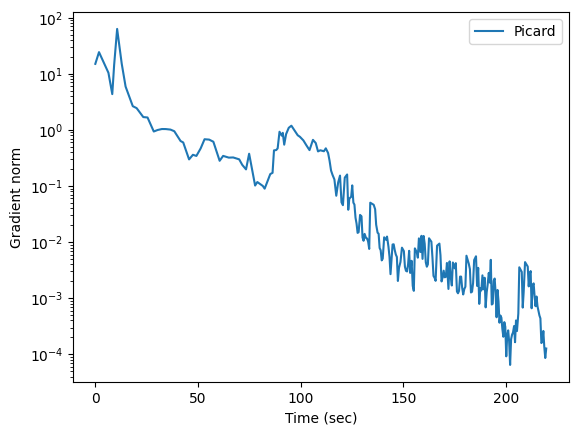